In [2]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4,
          'xtick.minor.visible': True,
          'ytick.minor.visible': True,}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [3]:
dco_types = const.DCO_TYPES.copy()
for i in range(len(dco_types)):
    dco_types.append(f"{dco_types[i]}_pessimistic")

In [4]:
f_detect_dfs = {
    dco_type: pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_f_detect.h5", key="f_detect") for dco_type in dco_types
}

In [37]:
model_labels={
    "fiducial": "Fiducial",
    "alpha_low": r"$\alpha_{\rm CE} = 0.1$",
    "alpha_high": r"$\alpha_{\rm CE} = 10$",
    "maltsev": r"M25 remnants",
    "no_ecsn": "No ECSN",
    "qcflag2": r"C14 $q_{\rm crit}$"
}
model_labels_long={
    "fiducial": "Fiducial",
    "alpha_low": r"Low efficiency CE, $\alpha_{\rm CE} = 0.1$",
    "alpha_high": r"High efficiency CE, $\alpha_{\rm CE} = 10$",
    "maltsev": r"Maltsev+2025 remnant masses",
    "no_ecsn": "No electron-capture supernovae",
    "qcflag2": r"Claeys+2014 critical mass ratios"
}

# Detection rate

In [5]:
n_targets = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/normalisations.h5", key="n_targets")

In [6]:
f_detect_dfs["BHBH"]["lisa_4yr_final_pos_SNRgt7"].mean()

np.float64(3.766329755214011e-05)

In [7]:
pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/maltsev/BHWD_f_detect.h5", key="f_detect")["lisa_4yr_final_pos_SNRgt7"].mean()

np.float64(9.908327905808385e-05)

In [8]:
n_targets

,BHBH,BHNS,BHWD,NSNS,NSWD,BHBH_pessimistic,BHNS_pessimistic,BHWD_pessimistic,NSNS_pessimistic,NSWD_pessimistic
fiducial,1.156180e+06,5.377530e+05,153906.420634,1.772587e+05,9.830759e+05,455451.208993,217089.766481,15972.788304,23364.207046,6.280733e+05
alpha_low,4.612208e+05,1.839881e+05,23970.095245,4.740926e+04,1.260655e+04,455156.529656,153498.178232,2885.998049,14046.963007,1.257546e+04
alpha_high,1.047672e+06,2.791683e+06,563743.976513,7.088412e+06,2.062352e+07,69255.766977,145908.695892,83.813071,158330.187273,2.204567e+05
maltsev,1.130808e+05,3.515489e+05,67588.265667,1.418633e+05,9.366492e+05,45513.293226,180919.017235,50.126945,7263.108746,6.081559e+05
no_ecsn,1.156096e+06,5.187438e+05,153472.636255,1.432408e+05,2.217977e+06,454421.495804,218262.805393,15855.001609,23174.030650,1.397880e+06
qcflag2,1.168815e+06,6.080998e+05,141006.321018,1.902701e+05,9.363472e+05,485707.280850,267398.001308,4515.161397,25947.176572,5.257712e+05


In [9]:
reload(detections)
df = detections.load_detections(const.VARIATIONS, n_targets)
for dco_type in dco_types:
    if "pess" in dco_type:
        continue
    det = df.loc["fiducial", :, dco_type.split("_")[0], "lisa"]["mid"].values
    print(dco_type, det[1] / det[0], det[3] / det[2])
df

BHBH 0.8894049892711997 0.8880605419401405
BHNS 0.7079317758191362 0.69002898142673
BHWD 0.9751005587605038 0.9520943698302354
NSNS 0.7859981415511356 0.6879414749583747
NSWD 0.9298487449183488 0.8978133869288871


lo        mid  \
model    variant      dco  detector position                            
fiducial              BHBH lisa     initial_pos  27.925775  46.972323   
                                    final_pos    24.163903  41.777418   
                           decigo   initial_pos   0.000000   1.787166   
                                    final_pos     0.000000   1.789930   
                      BHNS lisa     initial_pos  13.830575  23.245049   
...                                                    ...        ...   
qcflag2  _pessimistic NSNS decigo   final_pos     0.197965   0.445039   
                      NSWD lisa     initial_pos  57.397823  74.495005   
                                    final_pos    49.824093  65.095119   
                           decigo   initial_pos  65.994119  83.403738   
                                    final_pos    58.459115  74.945204   

                                                         hi  
model    variant      dco  detector position                 
fiducial              BHBH lisa     initial_pos   75.466914  
                                    final_pos     68.800393  
                           decigo   initial_pos    9.555506  
                                    final_pos      9.507995  
                      BHNS lisa     initial_pos   40.128069  
...                                                     ...  
qcflag2  _pessimistic NSNS decigo   final_pos      0.881778  
                      NSWD lisa     initial_pos   94.130125  
                                    final_pos     84.698337  
                           decigo   initial_pos  103.647338  
                                    final_pos     95.558214  

[240 rows x 3 columns]

In [35]:
reload(detections)
table = detections.detection_table(
    const.VARIATIONS, n_targets,
    model_labels=model_labels_long,
    duration=8,
    snr_lim=12,
    position="initial_pos"
)
print(table)

\begin{tabular}{lccccc}
\toprule
Model & BHBH & BHNS & BHWD & NSNS & NSWD \\
\midrule
Fiducial & $13.1^{+9.8}_{-6.2}$ & $8.0^{+6.5}_{-3.7}$ & $1.3^{+0.5}_{-0.4}$ & $0.8^{+0.7}_{-0.3}$ & $110^{+25}_{-22}$ \\
Optimistic CE & $39^{+27}_{-17}$ & $19.1^{+16.2}_{-8.1}$ & $9.6^{+4.4}_{-3.1}$ & $6.3^{+5.5}_{-2.7}$ & $173^{+50}_{-38}$ \\
Low efficiency CE, $\alpha_{\rm CE} = 0.1$ & $13.8^{+12.8}_{-6.5}$ & $4.8^{+6.2}_{-2.6}$ & $0.3^{+0.2}_{-0.1}$ & $0.7^{+0.5}_{-0.3}$ & $1.0^{+0.7}_{-0.5}$ \\
High efficiency CE, $\alpha_{\rm CE} = 10$ & $2.1^{+1.9}_{-1.0}$ & $5.8^{+3.8}_{-2.5}$ & $0.0^{+0.0}_{-0.0}$ & $6.9^{+3.7}_{-2.6}$ & $24.4^{+12.0}_{-8.8}$ \\
Maltsev+2025 remnant masses & $0.6^{+0.9}_{-0.4}$ & $7.3^{+4.8}_{-3.0}$ & $0.0^{+0.0}_{-0.0}$ & $0.3^{+0.3}_{-0.1}$ & $117^{+27}_{-22}$ \\
No ECSN & $13.0^{+9.9}_{-6.1}$ & $8.0^{+6.2}_{-3.7}$ & $1.3^{+0.6}_{-0.4}$ & $0.7^{+0.5}_{-0.3}$ & $158^{+67}_{-49}$ \\
Claeys+2014 critical mass ratios & $13.4^{+10.3}_{-6.2}$ & $9.6^{+7.3}_{-4.3}$ & $0.4^{+0.2}_{

In [36]:
reload(detections)
table = detections.detection_table(
    const.VARIATIONS, n_targets,
    model_labels=model_labels_long,
    duration=8,
    snr_lim=12,
    position="final_pos"
)
print(table)

\begin{tabular}{lccccc}
\toprule
Model & BHBH & BHNS & BHWD & NSNS & NSWD \\
\midrule
Fiducial & $11.6^{+9.1}_{-5.9}$ & $5.5^{+5.6}_{-2.8}$ & $1.2^{+0.6}_{-0.4}$ & $0.5^{+0.6}_{-0.3}$ & $99^{+25}_{-20}$ \\
Optimistic CE & $35^{+25}_{-16}$ & $13.9^{+13.0}_{-7.0}$ & $9.4^{+4.3}_{-3.1}$ & $5.1^{+5.0}_{-2.4}$ & $161^{+49}_{-37}$ \\
Low efficiency CE, $\alpha_{\rm CE} = 0.1$ & $12.6^{+11.7}_{-6.1}$ & $3.7^{+5.5}_{-2.2}$ & $0.3^{+0.2}_{-0.1}$ & $0.2^{+0.2}_{-0.1}$ & $1.0^{+0.6}_{-0.5}$ \\
High efficiency CE, $\alpha_{\rm CE} = 10$ & $2.0^{+1.8}_{-1.0}$ & $4.8^{+3.3}_{-2.2}$ & $0.0^{+0.0}_{-0.0}$ & $5.9^{+3.2}_{-2.4}$ & $22.1^{+11.4}_{-8.2}$ \\
Maltsev+2025 remnant masses & $0.6^{+0.9}_{-0.4}$ & $4.1^{+3.7}_{-2.2}$ & $0.0^{+0.0}_{-0.0}$ & $0.3^{+0.3}_{-0.1}$ & $104^{+26}_{-21}$ \\
No ECSN & $11.7^{+9.2}_{-5.7}$ & $5.6^{+5.3}_{-2.9}$ & $1.3^{+0.6}_{-0.4}$ & $0.3^{+0.4}_{-0.2}$ & $106^{+58}_{-39}$ \\
Claeys+2014 critical mass ratios & $12.0^{+9.7}_{-6.1}$ & $6.8^{+5.9}_{-3.6}$ & $0.4^{+0.2}_{-0

In [24]:
reload(detections)
table = detections.n_targets_table(const.VARIATIONS, n_targets, model_labels={
        "fiducial": "Fiducial",
        "alpha_low": r"$\alpha_{\rm CE} = 0.1$",
        "alpha_high": r"$\alpha_{\rm CE} = 10$",
        "maltsev": r"M25 remnants",
        "no_ecsn": "No ECSN",
        "qcflag2": r"C14 $q_{\rm crit}$"
    },)
print(table)

\begin{tabular}{lccccc}
\hline
Model & BHBH & BHNS & BHWD & NSNS & NSWD \\
 & [$10^5$] & [$10^5$] & [$10^4$] & [$10^4$] & [$10^5$] \\
\midrule
Fiducial & 4.55 & 2.17 & 1.60 & 2.34 & 6.28 \\
Optimistic CE & 11.56 & 5.38 & 15.39 & 17.73 & 9.83 \\
$\alpha_{\rm CE} = 0.1$ & 4.55 & 1.53 & 0.29 & 1.40 & 0.13 \\
$\alpha_{\rm CE} = 10$ & 0.69 & 1.46 & 0.008 & 15.83 & 2.20 \\
M25 remnants & 0.46 & 1.81 & 0.005 & 0.73 & 6.08 \\
No ECSN & 4.54 & 2.18 & 1.59 & 2.32 & 13.98 \\
C14 $q_{\rm crit}$ & 4.86 & 2.67 & 0.45 & 2.59 & 5.26 \\
\hline
\end{tabular}


In [12]:
df.loc["maltsev", :, "BHWD", "lisa"]

lo       mid        hi
variant      position                                 
             initial_pos  4.967792  6.663207  8.544930
             final_pos    4.966550  6.647429  8.682586
_pessimistic initial_pos  0.003684  0.004942  0.006337
             final_pos    0.003683  0.004930  0.006439

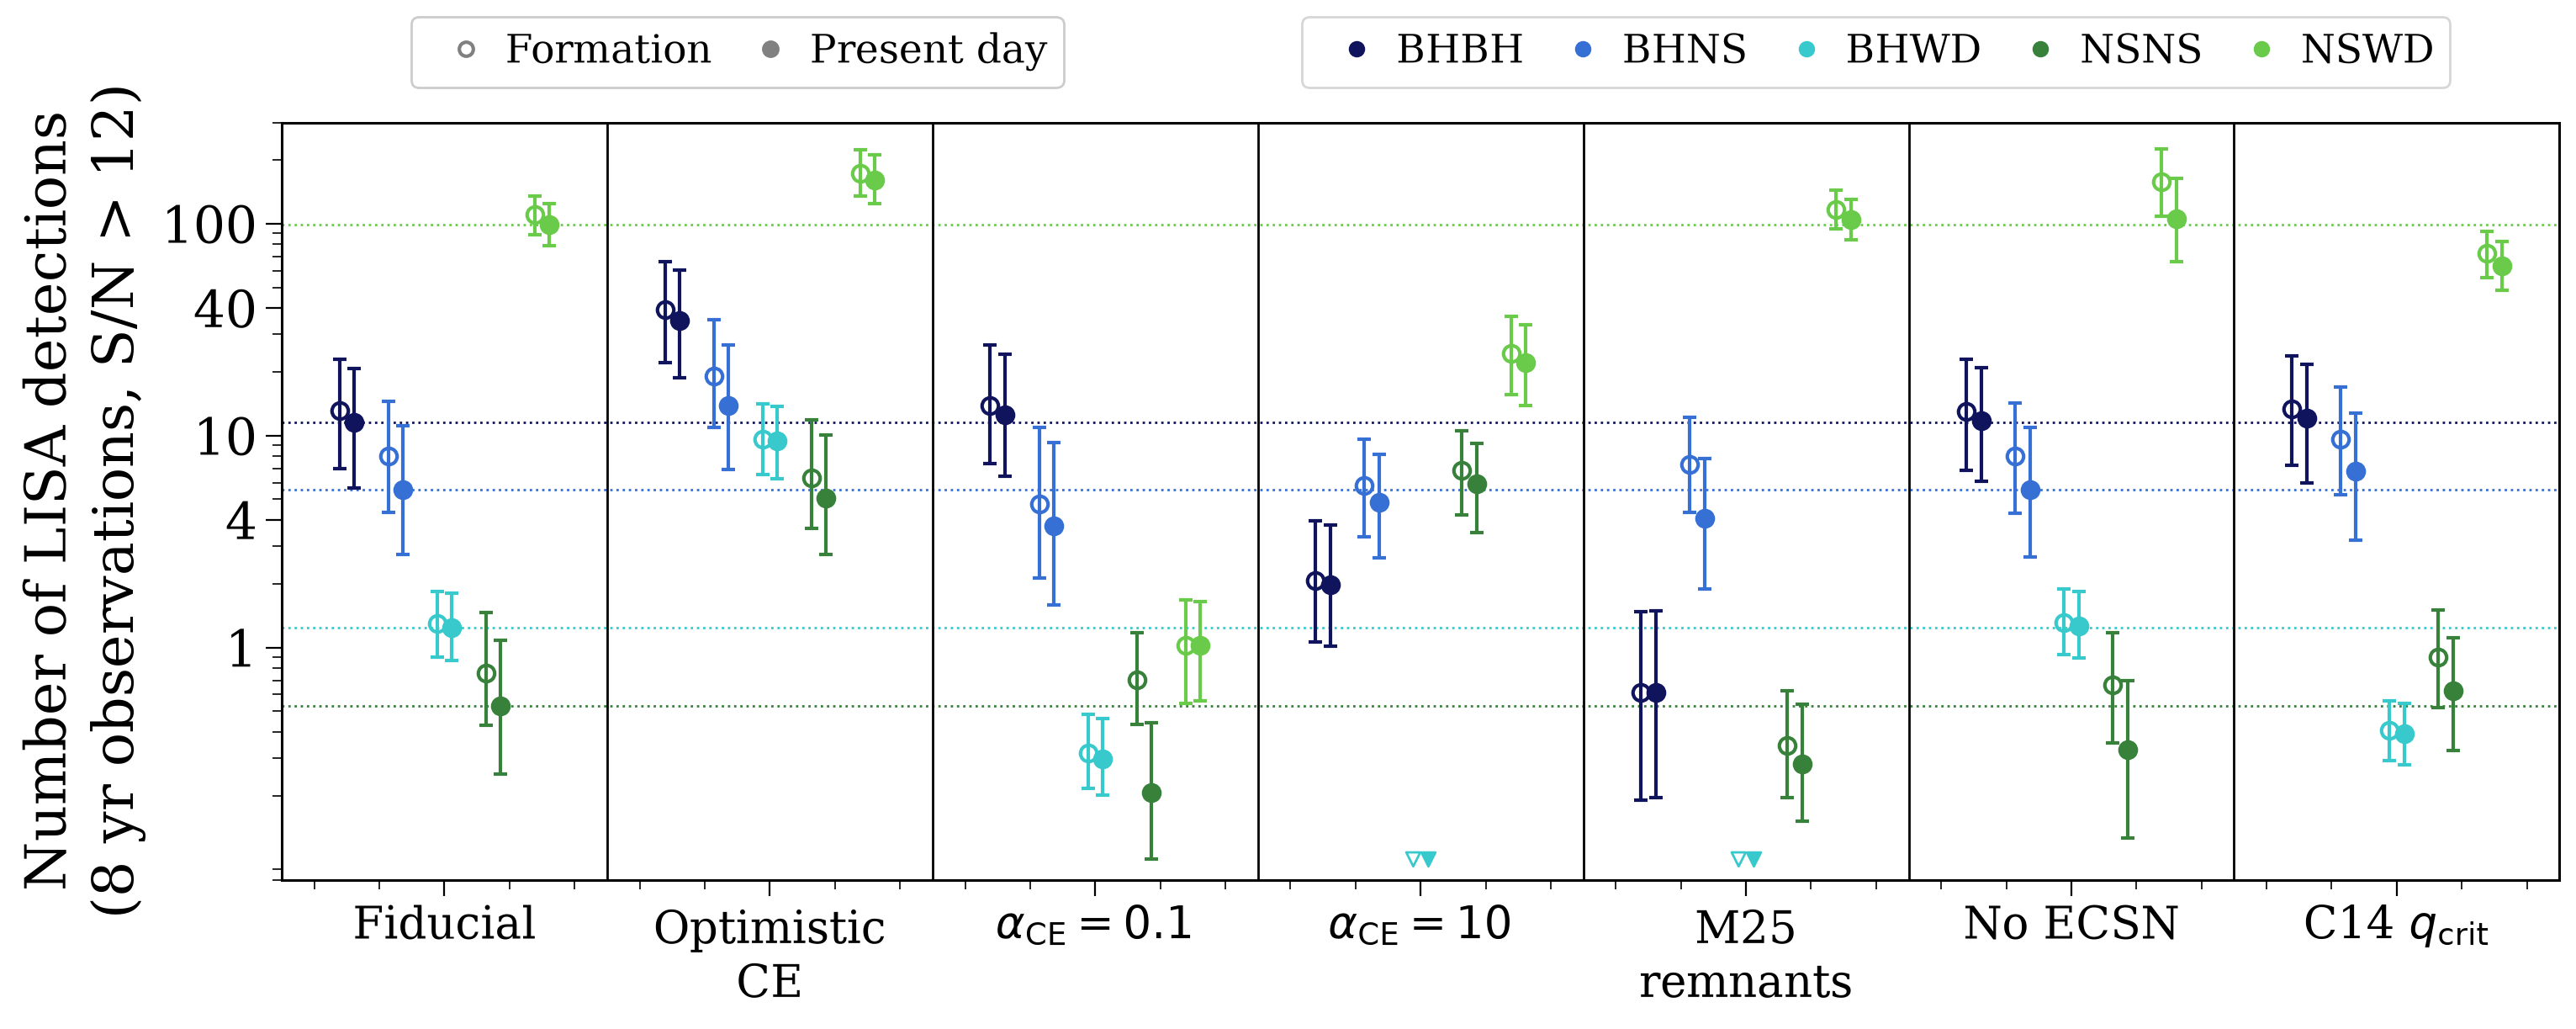

(<Figure size 1520x600 with 1 Axes>,
 <Axes: ylabel='Number of LISA detections\n(8 yr observations, S/N > 12)'>)

In [18]:
reload(detections)
detections.plot_detections(
    const.VARIATIONS, n_targets, detectors=["lisa"],
    save="../plots/n_detect.pdf", duration=8, show_sec_ax=False,
    column_labels={
        ("fiducial", "_pessimistic"): "Fiducial",
        ("fiducial", ""): "Optimistic\nCE",
        ("alpha_low", "_pessimistic"): r"$\alpha_{\rm CE} = 0.1$",
        ("alpha_high", "_pessimistic"): r"$\alpha_{\rm CE} = 10$",
        ("maltsev", "_pessimistic"): "M25\nremnants",
        ("no_ecsn", "_pessimistic"): "No ECSN",
        ("qcflag2", "_pessimistic"): r"C14 $q_{\rm crit}$"
    },
    ylim=(0.08, 300),
    snr_lim=12
)